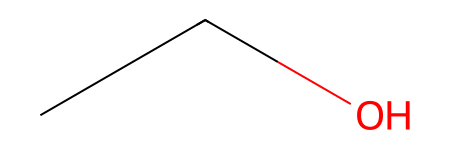

In [1]:
from rdkit import Chem
import numpy as np

mol = Chem.MolFromSmiles('CCO')
mol

In [3]:
adj = Chem.GetAdjacencyMatrix(mol)
adj

array([[0, 1, 0],
       [1, 0, 1],
       [0, 1, 0]], dtype=int32)

In [4]:
#원자 index 출력
for atom in mol.GetAtoms():
    print(atom.GetIdx(), atom.GetSymbol())

0 C
1 C
2 O


In [5]:
#화학 결합 정보 출력
for bond in mol.GetBonds():
    print(bond.GetBeginAtomIdx(), '-', bond.GetEndAtomIdx())

0 - 1
1 - 2


In [7]:
#topological distance: node에 도달하려면 몇개의 edge를 거쳐야 할까?
dm = Chem.GetDistanceMatrix(mol)
dm

array([[0., 1., 2.],
       [1., 0., 1.],
       [2., 1., 0.]])

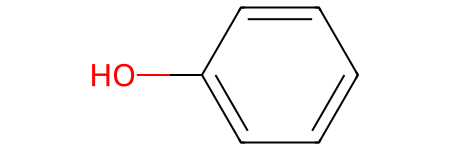

In [9]:
mol = Chem.MolFromSmiles('c1ccc(O)cc1')  # 페놀
mol

In [10]:
for atom in mol.GetAtoms():
    print(f"{atom.GetIdx()}: {atom.GetSymbol()}, 결합수={atom.GetDegree()}, 방향족={atom.GetIsAromatic()}")

0: C, 결합수=2, 방향족=True
1: C, 결합수=2, 방향족=True
2: C, 결합수=2, 방향족=True
3: C, 결합수=3, 방향족=True
4: O, 결합수=1, 방향족=False
5: C, 결합수=2, 방향족=True
6: C, 결합수=2, 방향족=True


In [11]:
adj = Chem.GetAdjacencyMatrix(mol)
adj

array([[0, 1, 0, 0, 0, 0, 1],
       [1, 0, 1, 0, 0, 0, 0],
       [0, 1, 0, 1, 0, 0, 0],
       [0, 0, 1, 0, 1, 1, 0],
       [0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0, 0, 1],
       [1, 0, 0, 0, 0, 1, 0]], dtype=int32)

In [12]:
dm = Chem.GetDistanceMatrix(mol)
dm

array([[0., 1., 2., 3., 4., 2., 1.],
       [1., 0., 1., 2., 3., 3., 2.],
       [2., 1., 0., 1., 2., 2., 3.],
       [3., 2., 1., 0., 1., 1., 2.],
       [4., 3., 2., 1., 0., 2., 3.],
       [2., 3., 2., 1., 2., 0., 1.],
       [1., 2., 3., 2., 3., 1., 0.]])

### Adjacency matrix와 Distance matrix를 기반으로 계산할 수 있는 descriptor는 어떤 것들이 있을까?